In [1]:
!pip install tensorflowjs split-folders --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-bigquery 3.40.1 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
db-dtypes 1.5.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


In [2]:
import os
import zipfile
import shutil
import splitfolders
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import random
from google.colab import files

In [3]:
if not os.path.exists('ewaste_dataset'):
    with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
        zip_ref.extractall('ewaste_dataset')

source_dir = ''
for root, dirs, _ in os.walk('ewaste_dataset'):
    dirs_lower = [d.lower() for d in dirs]
    if 'train' in dirs_lower:
        source_dir = os.path.join(root, dirs[dirs_lower.index('train')])
        break

if os.path.exists('dataset_split'):
    shutil.rmtree('dataset_split')

splitfolders.ratio(source_dir, output="dataset_split", seed=42, ratio=(0.8, 0.1, 0.1))

train_dir = os.path.join('dataset_split', 'train')
val_dir = os.path.join('dataset_split', 'val')
test_dir = os.path.join('dataset_split', 'test')

Copying files: 2400 files [00:00, 4750.81 files/s]


In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(150, 150), batch_size=32, class_mode='categorical'
)

val_generator = test_datagen.flow_from_directory(
    val_dir, target_size=(150, 150), batch_size=32, class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(150, 150), batch_size=32, class_mode='categorical', shuffle=False
)

kelas_dataset = list(train_generator.class_indices.keys())

Found 1920 images belonging to 10 classes.
Found 240 images belonging to 10 classes.
Found 240 images belonging to 10 classes.


In [5]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(150, 150, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(kelas_dataset), activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('model_terbaik.h5', monitor='val_accuracy', save_best_only=True)
]

history = model.fit(train_generator, epochs=20, validation_data=val_generator, callbacks=callbacks)

/tmp/ipykernel_616/3545871073.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.5365 - loss: 2.3847

60/60 ━━━━━━━━━━━━━━━━━━━━ 53s 472ms/step - accuracy: 0.5389 - loss: 2.3681 - val_accuracy: 0.8833 - val_loss: 0.2935
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 190ms/step - accuracy: 0.8273 - loss: 0.5578 - val_accuracy: 0.8542 - val_loss: 0.3855
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.8662 - loss: 0.4365

60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 196ms/step - accuracy: 0.8663 - loss: 0.4364 - val_accuracy: 0.9125 - val_loss: 0.2706
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.8851 - loss: 0.3637

60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 196ms/step - accuracy: 0.8851 - loss: 0.3638 - val_accuracy: 0.9250 - val_loss: 0.2655
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 217ms/step - accuracy: 0.8923 - loss: 0.3139 - val_accuracy: 0.9208 - val_loss: 0.2947
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 189ms/step - accuracy: 0.9252 - loss: 0.2341 - val_accuracy: 0.9208 - val_loss: 0.2465
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 188ms/step - accuracy: 0.9281 - loss: 0.2316 - val_accuracy: 0.9125 - val_loss: 0.2362
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 189ms/step - accuracy: 0.9285 - loss: 0.2060 - val_accuracy: 0.9250 - val_loss: 0.2380
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.9286 - loss: 0.2159

60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 197ms/step - accuracy: 0.9286 - loss: 0.2159 - val_accuracy: 0.9333 - val_loss: 0.2258
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 191ms/step - accuracy: 0.9402 - loss: 0.1986 - val_accuracy: 0.9292 - val_loss: 0.2138
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 181ms/step - accuracy: 0.9370 - loss: 0.1932 - val_accuracy: 0.9250 - val_loss: 0.2869
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 190ms/step - accuracy: 0.9409 - loss: 0.1811 - val_accuracy: 0.9167 - val_loss: 0.2515
Epoch 13/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 191ms/step - accuracy: 0.9407 - loss: 0.1740 - val_accuracy: 0.9167 - val_loss: 0.3476
Epoch 14/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 188ms/step - accuracy: 0.9393 - loss: 0.1892 - val_accuracy: 0.9292 - val_loss: 0.2511


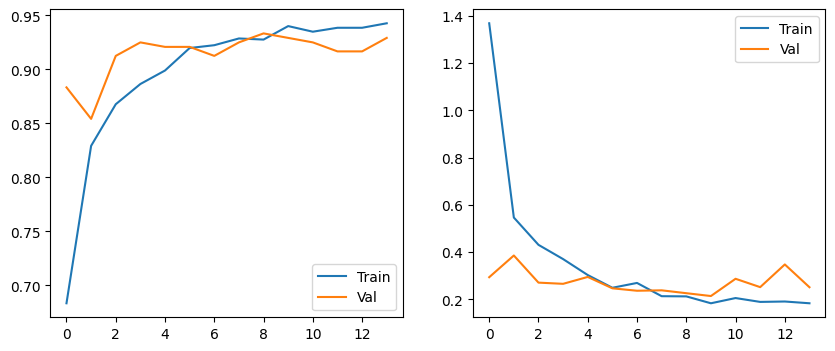

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9357 - loss: 0.1842


[0.28359872102737427, 0.925000011920929]

In [6]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.legend()
plt.show()

model.evaluate(test_generator)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Gambar Asli: Printer
Tebakan Model: PCB


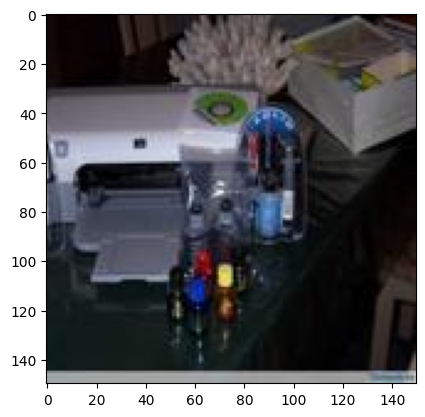

In [7]:
kelas_acak = random.choice(kelas_dataset)
folder_kelas = os.path.join(test_dir, kelas_acak)
file_gambar = random.choice(os.listdir(folder_kelas))
path_gambar = os.path.join(folder_kelas, file_gambar)

img = image.load_img(path_gambar, target_size=(150, 150))
plt.imshow(img)
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
images = np.vstack([x])

classes = model.predict(images, batch_size=10)
hasil_prediksi = kelas_dataset[np.argmax(classes[0])]

print(f"Gambar Asli: {kelas_acak}")
print(f"Tebakan Model: {hasil_prediksi}")

In [8]:
import os
import tensorflow as tf
from google.colab import files

model.export("saved_model")

converter = tf.lite.TFLiteConverter.from_saved_model("saved_model")
tflite_model = converter.convert()

os.makedirs('tflite', exist_ok=True)
with open('tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)

with open('tflite/label.txt', 'w') as f:
    for kelas in kelas_dataset:
        f.write(f"{kelas}\n")

!tensorflowjs_converter --input_format=tf_saved_model saved_model tfjs_model

!pip freeze > requirements.txt

with open('README.md', 'w') as f:
    f.write("# Proyek Klasifikasi Gambar\n\nProyek ini menggunakan algoritma CNN dengan arsitektur Transfer Learning MobileNetV2 ditambah layer Conv2D dan MaxPooling2D untuk mengklasifikasi 10 jenis dataset sampah elektronik (E-Waste). Dataset telah dibagi secara mandiri menggunakan library split-folders menjadi Train, Validation, dan Test dengan rasio 80:10:10.")

!rm -f Submission_Klasifikasi.zip
!zip -r Submission_Klasifikasi.zip saved_model tflite tfjs_model requirements.txt README.md

files.download('Submission_Klasifikasi.zip')

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  132630802564112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132630802566032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132630802567760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132630802565840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132630802569104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132630802568336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132630802566992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132630802567376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132630802565264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132630802567952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13263080256680

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>